<a href="https://colab.research.google.com/github/angelfrancomorales/INFO648/blob/main/Problem_Set_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 1: Class Distribution and a Baseline**

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [155]:
df=pd.read_csv('/content/churn_synthetic_600.csv')

In [156]:
df.head()

,CustomerID,Churn,TenureMonths,MonthlyCharge,ContractType,PaymentMethod,SupportCalls
0,C0001,1,20,86.27,One-Year,Credit Card,3
1,C0002,0,1,64.80,Month-to-Month,Electronic Check,1
2,C0003,1,20,75.02,Month-to-Month,Credit Card,3
3,C0004,0,18,61.21,Month-to-Month,Bank Transfer,2
4,C0005,0,63,66.20,Two-Year,Bank Transfer,0


In [157]:
df.describe()

,Churn,TenureMonths,MonthlyCharge,SupportCalls
count,600.000000,600.000000,600.000000,600.00000
mean,0.236667,37.461667,69.517050,1.22000
std,0.425391,20.299967,19.687343,1.18347
min,0.000000,1.000000,25.000000,0.00000
25%,0.000000,20.000000,56.697500,0.00000
50%,0.000000,38.000000,68.765000,1.00000
75%,0.000000,54.000000,82.845000,2.00000
max,1.000000,72.000000,138.990000,6.00000


In [158]:
model_df=df.copy()

In [159]:
class_counts = model_df['Churn'].value_counts()
print(class_counts)

Churn
0    458
1    142
Name: count, dtype: int64


In [160]:
class_proportions = model_df['Churn'].value_counts(normalize=True)
print(class_proportions)

Churn
0    0.763333
1    0.236667
Name: proportion, dtype: float64


In [161]:
majority_class = class_proportions.idxmax()
minority_class = class_proportions.idxmin()
print("Majority class:", majority_class)
print("Minority class:", minority_class)

Majority class: 0
Minority class: 1


1. The data set is imbalanced. With a majority of 458 (76.3%) and a minority of 142 (23.6%), with a 3.2 ratio.

2. When one group dominates in the dataframe, then the model focuses on that data, which then provides inaccurate information for the minority group.

3. The model is quickly grouping the majority percentage without learning specific patterns. This can be misleading since the model is not learning from the minority class, which could affect the final class percentage.

**Part 2: Preprocessing Plan**

In [162]:
numeric_features = ['TenureMonths', 'MonthlyCharge', 'SupportCalls']
categorical_features = ['ContractType', 'PaymentMethod']
print(numeric_features)
print(categorical_features)


['TenureMonths', 'MonthlyCharge', 'SupportCalls']
['ContractType', 'PaymentMethod']


In [163]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])


Logistic regression computes a weighted sum of the features, so we use StandardScaler to prevent features with large numeric ranges from dominating the model. Categorical features cannot be multiplied by a coefficient, so OneHotEncoder converts each category into a binary column.

Fitting inside a Pipeline matters because if you fit the scaler to all 600 rows before splitting, the test set will already have influenced the transformation. That means there is data leakage which makes the accuracy look better than what it really is. Keeping everything inside the Pipeline helps the Scaler and encoder to only use the training data.

**Part 3: Build the Pipeline**

In [164]:
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

In [165]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Training set : {X_train.shape[0]} rows (churn rate: {y_train.mean():.2%})")
print(f"Test set     : {X_test.shape[0]} rows (churn rate: {y_test.mean():.2%})")

Training set : 480 rows (churn rate: 23.75%)
Test set     : 120 rows (churn rate: 23.33%)


In [166]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [167]:
print("Pipeline fitted successfully.")
print(pipe)

Pipeline fitted successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['TenureMonths',
                                                   'MonthlyCharge',
                                                   'SupportCalls']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['ContractType',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


In [168]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['TenureMonths',
                                                   'MonthlyCharge',
                                                   'SupportCalls']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['ContractType',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

Part 1 only showed that about 23.7% of customers churned. Stratify=y guarantees that both the training and test sets preserve the same class ratio as the full data set. This will ensure the model trains on a representative mix and that the evaluation metrics reflect realistic class proportions.

**Part 4: Evaluation**

In [169]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = pipe.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[84  8]
 [16 12]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.88        92
           1       0.60      0.43      0.50        28

    accuracy                           0.80       120
   macro avg       0.72      0.67      0.69       120
weighted avg       0.78      0.80      0.79       120



Text(70.72222222222221, 0.5, 'Actual Stayed')

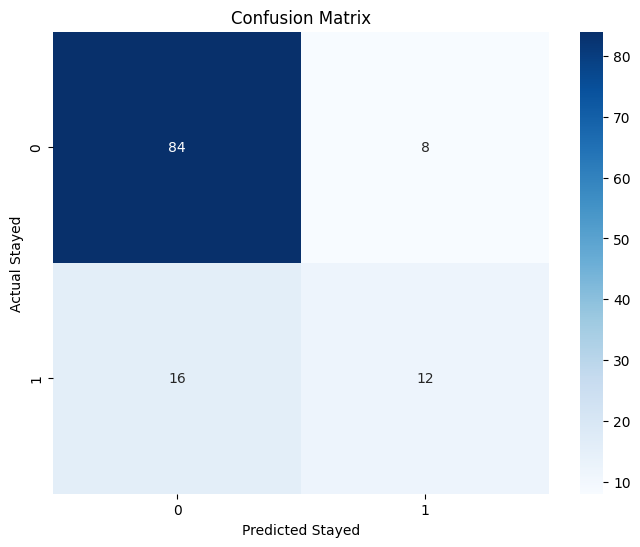

In [170]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Stayed')
plt.ylabel('Actual Stayed')

True Negative (TN) 84 - Customers who actually stayed, and the model correctly predicted it.

False Positive (FP) 8 - Customers who actually stayed, but the model incorrectly flagged as likely churners.

False Negative (FN) 16 - Customers who actually churned, and the model predicted they would stay.

True Positive (TP) 12 - Customers who actually churned, and the model correctly identified it beforehand.

**Precision** = TP / (TP + FP) = 12 / 20 = 0.60. Of every customer the model flagged
as a churner, 60% actually did churn and 40% were false alarms.

**Recall** = TP / (TP + FN) = 12 / 28 = 0.43. Of all customers who actually churned,
the model caught only 43%; the remaining 57% were missed entirely.

Did the model actually learn something useful?

Yes, the model achieved 80% accuracy versus the 76.3% majority-class baseline, a 3.7% improvement. The model correctly identified 12 genuine churners that the business can actually act on.

**Part 5: Interpreting the Coefficients**

In [171]:
ohe_names = (pipe.named_steps['preprocessor']
             .named_transformers_['cat']
             .get_feature_names_out(categorical_features))

print(ohe_names)
# ['ContractType_One-Year' 'ContractType_Two-Year'
#  'PaymentMethod_Credit Card' 'PaymentMethod_Electronic Check']

['ContractType_One-Year' 'ContractType_Two-Year'
 'PaymentMethod_Credit Card' 'PaymentMethod_Electronic Check']


In [172]:
all_features = numeric_features + list(ohe_names)
coefs = pipe.named_steps['classifier'].coef_[0]

coef_df = (pd.DataFrame({'Feature': all_features, 'Coefficient': coefs})
           .sort_values('Coefficient', ascending=False)
           .reset_index(drop=True))

print(coef_df)

                          Feature  Coefficient
0                   MonthlyCharge     0.586475
1                    SupportCalls     0.399425
2  PaymentMethod_Electronic Check     0.163387
3       PaymentMethod_Credit Card     0.014750
4           ContractType_One-Year    -0.781311
5                    TenureMonths    -0.915028
6           ContractType_Two-Year    -1.324002


Out of all the features, ContractType_Two-Year has the largest coefficient by absolute value, -1.32. Customers on this two-year contract are less likely to churn compared with month-to-month customers. From a retention standpoint, getting customers to switch from a month-to-month plan to a two-year contract is one of the most effective levers.

**Part 6: The Precision–Recall Tradeoff**

Low precision means the model flags customers who were never going to leave, sending them retention offers they don't need. Low recall means real churners go undetected and don't receive a retention offer, so the business loses those customers entirely.

For this retention program, recall should be the priority. The loss of a customer is almost always greater than the cost of a retention offer or a courtesy call. With a recall of 43%, this means the model is missing almost half of the leaving customers. However, at 60% precision, the organization may be losing resources, which could significantly increase operational costs.